# Parte 1 — Regressão: Student Performance

Previsão da nota média (`score`) de alunos do curso de Matemática a partir de atributos demográficos, familiares e de hábitos de estudo. Como `score` é contínuo (0 a 20), trata-se de um problema de **regressão**. A métrica principal é o **RMSE**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import sklearn as sk
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn import linear_model, neighbors, svm, tree, ensemble
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV

## 1.1) Análise Exploratória (EDA)

In [4]:
df_train = pd.read_csv('train.csv')
df_train.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67


In [5]:
print("Dimensões:", df_train.shape)
print("Valores ausentes no total:", df_train.isna().sum().sum())
df_train.describe()

Dimensões: (395, 31)
Valores ausentes no total: 0


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,score
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.679139
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.696912
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.330000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.330000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,10.670000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.330000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.330000


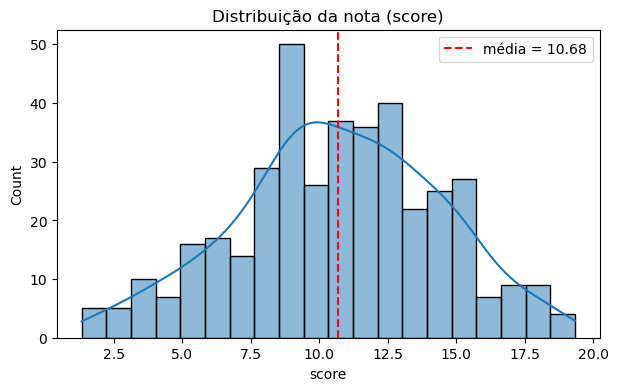

In [6]:
plt.figure(figsize=(7,4))
sns.histplot(df_train["score"], bins=20, kde=True)
plt.axvline(df_train["score"].mean(), color="red", linestyle="--",
            label=f'média = {df_train["score"].mean():.2f}')
plt.title("Distribuição da nota (score)"); plt.xlabel("score"); plt.legend()
plt.show()

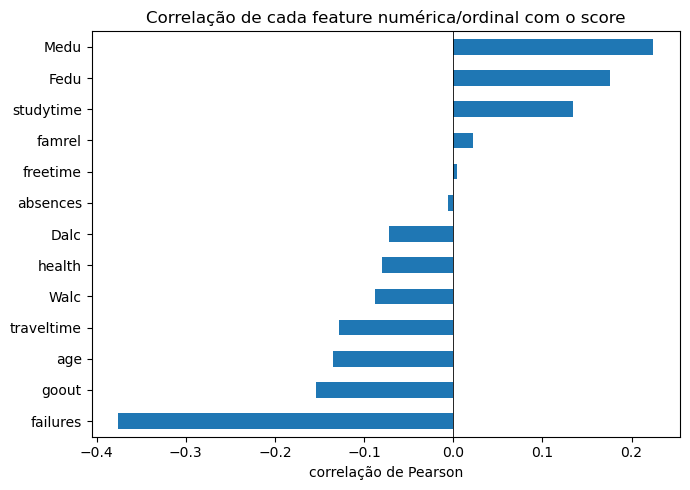

failures     -0.376
goout        -0.155
age          -0.135
traveltime   -0.128
Walc         -0.088
health       -0.080
Dalc         -0.073
absences     -0.006
freetime      0.004
famrel        0.022
studytime     0.135
Fedu          0.176
Medu          0.224
Name: score, dtype: float64

In [7]:
num_ord = ["age","absences","Medu","Fedu","traveltime","studytime","failures",
           "famrel","freetime","goout","Dalc","Walc","health"]
corr = df_train[num_ord + ["score"]].corr()["score"].drop("score").sort_values()

plt.figure(figsize=(7,5))
corr.plot(kind="barh")
plt.title("Correlação de cada feature numérica/ordinal com o score")
plt.xlabel("correlação de Pearson"); plt.axvline(0, color="black", linewidth=0.6)
plt.tight_layout(); plt.show()
corr.round(3)

In [6]:
# comparação de médias para algumas features categóricas
for col in ["higher", "schoolsup", "sex"]:
    print(df_train.groupby(col)["score"].mean().round(2).to_string(), "\n")

higher
no      7.65
yes    10.84 

schoolsup
no     10.87
yes     9.36 

sex
F    10.32
M    11.07 



**Observações da EDA**

- **Sem valores ausentes** e sem coluna `id`: nenhuma limpeza é necessária.
- O `score` se concentra em torno de **10.7** (desvio ~3.7), com uma cauda à esquerda — há alunos com notas muito baixas, algumas próximas de zero.
- Entre as features numéricas/ordinais, `failures` (reprovações passadas) é a mais correlacionada com a nota, e **negativamente** (≈ −0.38): quem já reprovou tende a ter nota menor. Na direção positiva, a escolaridade dos pais (`Medu`, `Fedu`) e o tempo de estudo (`studytime`) puxam a nota para cima, mas de forma fraca.
- Comparando grupos, alunos que **querem cursar o ensino superior** (`higher = yes`) têm nota bem maior; quem recebe **apoio escolar extra** (`schoolsup = yes`) tem nota um pouco menor — provavelmente porque o apoio é dado justamente a quem tem dificuldade.
- Importante: `score = média(G1, G2, G3)`, mas as notas parciais **não estão entre as features** (foram removidas de propósito). Isso torna o problema honestamente difícil — prevemos desempenho pelo *perfil* do aluno, não por notas anteriores —, então não se deve esperar um RMSE muito baixo.

**Features Numéricas:** age, absences

**Features Ordinais:** Medu, Fedu, traveltime, studytime, failures, famrel, freetime, goout, Dalc, Walc, health

**Features Nominais:**
- Binárias: school, sex, address, famsize, Pstatus
- Yes/No: schoolsup, famsup, paid, activities, nursery, higher, internet, romantic
- Múltiplas categorias: Mjob, Fjob, reason, guardian

### 1.2) Pré-processamento

In [7]:
X = df_train.drop(columns = "score")
y = df_train["score"]

numericas = ["age", "absences"]

ordinais = ["Medu","Fedu","traveltime","studytime","failures",
             "famrel","freetime","goout","Dalc","Walc","health"]

nominais  = ["school","sex","address","famsize","Pstatus","Mjob","Fjob",
             "reason","guardian","schoolsup","famsup","paid","activities",
             "nursery","higher","internet","romantic"]

pre = ColumnTransformer([
        ("num", StandardScaler(), numericas + ordinais), # num = numerico
        ("cat", OneHotEncoder(handle_unknown="ignore"), nominais), # cat = categorico
])

Separei as features de acordo com seus tipos.
Por meio do ColumnTransformer, lidei com os tipos mistos dos dados. Com o StandardScaler() coloquei as features numericas e ordinais na mesma escala (por padrão média 0 e desvio 1) para padronização. Como a técnica de regularização escolhida foi o Ridge, foi necessário padronizar os valores para que a régua de penalização dos coeficientes de cada feature seja a mesma.

### 1.3) Modelos de inferência

In [8]:
modelos = {
    "LinearRegression": linear_model.LinearRegression(),
    "Ridge":            linear_model.Ridge(),
    "Lasso":            linear_model.Lasso(),
    "ElasticNet":       linear_model.ElasticNet(),
    "KNN":              neighbors.KNeighborsRegressor(),
    "SVR":              svm.SVR(),
    "DecisionTree":     tree.DecisionTreeRegressor(random_state=42),
    "RandomForest":     ensemble.RandomForestRegressor(random_state=42),
    "GradientBoosting": ensemble.GradientBoostingRegressor(random_state=42),
}

          modelo  RMSE  desvio
    RandomForest 3.238   0.174
GradientBoosting 3.287   0.052
             SVR 3.342   0.245
           Ridge 3.452   0.104
LinearRegression 3.459   0.111
      ElasticNet 3.498   0.259
           Lasso 3.563   0.265
             KNN 3.596   0.265
    DecisionTree 4.661   0.416


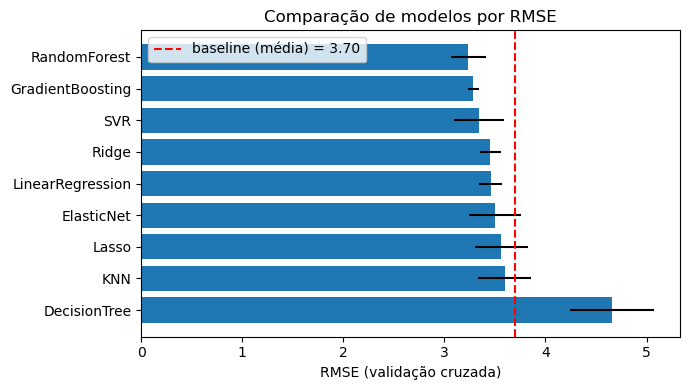

In [10]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

resultados = []
for nome, modelo in modelos.items():
    pipe = Pipeline([("pre", pre), ("modelo", modelo)])
    rmse = -cross_val_score(pipe, X, y, cv=cv, scoring="neg_root_mean_squared_error")
    resultados.append({"modelo": nome, "RMSE": rmse.mean(), "desvio": rmse.std()})

resultados = pd.DataFrame(resultados).sort_values("RMSE").reset_index(drop=True)
print(resultados.round(3).to_string(index=False))

plt.figure(figsize=(7,4))
plt.barh(resultados["modelo"], resultados["RMSE"], xerr=resultados["desvio"])
plt.axvline(y.std(), color="red", linestyle="--", label=f"baseline (média) = {y.std():.2f}")
plt.gca().invert_yaxis(); plt.xlabel("RMSE (validação cruzada)"); plt.legend()
plt.title("Comparação de modelos por RMSE"); plt.tight_layout(); plt.show()

### 1.4) Métrica e escolha do modelo

**Piso de comparação (baseline).** Um modelo que chuta a nota média (~10.7) para todos tem RMSE ≈ **3.70** (o desvio-padrão do `score`). Qualquer modelo só tem valor se ficar **abaixo** disso.

**Leitura da comparação.** Os ensembles de árvore (RandomForest e GradientBoosting) lideram; a árvore de decisão sozinha faz *overfitting* e fica pior que o baseline (RMSE ≈ 4.66); o KNN é o mais fraco dos que batem o baseline; os modelos lineares ficam no meio. Todos os bons modelos batem o baseline, mas por pouca margem — coerente com um problema difícil.

**Modelo escolhido: Gradient Boosting.** RandomForest e GradientBoosting empatam praticamente no RMSE, mas o **GradientBoosting tem o menor desvio entre folds** (≈ 0.05 contra ≈ 0.17), ou seja, é o mais **estável** — seu desempenho quase não depende de qual pedaço dos dados caiu no teste. Por isso ele é o candidato levado ao ajuste de hiperparâmetros.

### Ajuste de hiperparâmetros (GridSearchCV)

In [11]:
pipe = Pipeline([("pre", pre), ("reg", ensemble.GradientBoostingRegressor(random_state=42))])
grade = {
    "reg__n_estimators":  [100, 300],
    "reg__learning_rate": [0.05, 0.1],
    "reg__max_depth":     [2, 3],
}
gs = GridSearchCV(pipe, grade, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
gs.fit(X, y)
print("Melhores hiperparâmetros:", gs.best_params_)
print("RMSE (CV) do modelo ajustado:", round(-gs.best_score_, 3))

Melhores hiperparâmetros: {'reg__learning_rate': 0.1, 'reg__max_depth': 2, 'reg__n_estimators': 100}
RMSE (CV) do modelo ajustado: 3.213


In [12]:
# métricas complementares (médias por fold), para interpretar o modelo final
final = gs.best_estimator_
mae = -cross_val_score(final, X, y, cv=cv, scoring="neg_mean_absolute_error").mean()
r2  =  cross_val_score(final, X, y, cv=cv, scoring="r2").mean()
print(f"RMSE = {-gs.best_score_:.3f}")
print(f"MAE  = {mae:.3f}")
print(f"R2   = {r2:.3f}")

RMSE = 3.213
MAE  = 2.541
R2   = 0.228


**Interpretação do modelo final.** O Gradient Boosting ajustado (árvores rasas: `max_depth=2`, `learning_rate=0.1`, 100 árvores) atinge:

- **RMSE ≈ 3.21** — erro típico de ~3,2 pontos na escala de 0 a 20 (lembrando que ele pesa mais os erros grandes).
- **MAE ≈ 2.54** — o erro absoluto médio é menor que o RMSE, o que confirma que **poucos erros grandes** (os alunos de nota muito baixa) puxam o RMSE para cima.
- **R² ≈ 0.23** — o modelo explica cerca de **23% da variação** das notas.

Ou seja: o perfil do aluno carrega *algum* sinal sobre desempenho, mas modesto — o que é esperado e honesto, já que as notas parciais foram removidas. Um RMSE muito menor seria sinal de vazamento, não de mérito.

## Parte 3 — Previsão no test e submissão

O `GridSearchCV`, por padrão (`refit=True`), **já retreinou o melhor modelo em todo o `train`** — então `gs.best_estimator_` está pronto para prever. Como é um `Pipeline`, ele aplica ao `test.csv` exatamente o mesmo pré-processamento (o `transform` com a média/desvio e as categorias aprendidas no treino), sem vazamento e sem precisar codificar nada à mão.

In [8]:
df_test = pd.read_csv("test.csv")

pred = gs.best_estimator_.predict(df_test)

submission = pd.DataFrame({
    "id": range(len(df_test)),
    "score": np.round(pred, 2)
})
submission.to_csv("submission.csv", index=False)

# conferências obrigatórias antes de submeter
assert len(submission) == len(df_test), "número de linhas não bate com o test"
assert submission["score"].isna().sum() == 0, "há NaN nas previsões"
print("linhas:", len(submission))
print("faixa das previsões:", submission["score"].min(), "a", submission["score"].max())
submission.head()

NameError: name 'gs' is not defined

## Conclusão

Partindo de 395 alunos com 30 atributos mistos (numéricos, ordinais e categóricos), o fluxo foi: entender os dados (EDA), tratar os tipos mistos com um `ColumnTransformer` (padronização para os numéricos/ordinais e *one-hot* para os nominais) e comparar nove modelos sob a mesma validação cruzada (5 folds, embaralhados), usando o RMSE como métrica.

O **Gradient Boosting** foi escolhido por combinar o melhor RMSE após ajuste (**≈ 3.21**) com a maior estabilidade entre folds. É uma melhora real, ainda que modesta, sobre o baseline de 3.70, explicando ~23% da variação das notas.

A limitação central é intrínseca ao problema: sem as notas parciais (G1, G2), prever o desempenho apenas pelo perfil socioeconômico e de hábitos tem teto baixo. Caminhos para tentar melhorar: ajuste de hiperparâmetros mais amplo (inclusive no RandomForest), engenharia de features (ex.: combinar `Dalc`+`Walc`, ou `Medu`+`Fedu`) e testar `xgboost`/`lightgbm`. Ainda assim, dado o tamanho e a natureza do dataset, RMSE em torno de 3.2 é um resultado coerente.

Como o `test.csv` tem apenas 40 linhas, o RMSE do leaderboard vai **oscilar** em torno dessa estimativa — a validação cruzada no `train` é o número mais confiável para julgar o modelo.